### Student Name: Feliciann Elliot
### Course: MAI5301 - Foundations Of Large Language Models
### Activity: Assigment #4

In [1]:
import math, os, time, random
from dataclasses import dataclass
from typing import Optional, Dict, Tuple, List, Literal

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
def seed_everything(seed: int = 1337):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(1337)

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt -O shakespeare.txt

--2026-03-02 00:35:51--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘shakespeare.txt’

shakespeare.txt     100%[===================>]   1.06M  --.-KB/s    in 0.05s   

2026-03-02 00:35:51 (22.2 MB/s) - ‘shakespeare.txt’ saved [1115394/1115394]



In [5]:
# tinyshakespeare Dataset
DATA_PATH = "shakespeare.txt"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw_text = f.read()

print(raw_text[:500])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [6]:
from collections import Counter
import re

In [7]:
# Tokenizer
class SimpleTokenizer:
    def __init__(self, vocab=None, unk_token=""):
        self.unk_token = unk_token
        self.vocab = vocab or {unk_token: 0}
        self.inv_vocab = {i: t for t, i in self.vocab.items()}

    def _tokenize(self, text: str):
        # Basic regex: words and punctuation
        return re.findall(r"\w+|[^\w\s]", text, re.UNICODE)

    def build_vocab(self, texts, min_freq=1):
        counter = Counter()
        for text in texts:
            counter.update(self._tokenize(text))

        # Start fresh but keep unk at 0
        self.vocab = {self.unk_token: 0}
        idx = 1
        for token, freq in counter.items():
            if freq >= min_freq and token not in self.vocab:
                self.vocab[token] = idx
                idx += 1

        self.inv_vocab = {i: t for t, i in self.vocab.items()}

    def encode(self, text: str):
        tokens = self._tokenize(text)
        return [self.vocab.get(t, self.vocab[self.unk_token]) for t in tokens]

    def decode(self, ids):
        tokens = [self.inv_vocab.get(i, self.unk_token) for i in ids]
        # simple join with spacing rules
        out = ""
        for t in tokens:
            if re.match(r"[^\w\s]", t):  # punctuation
                out += t
            else:
                out += (" " if out else "") + t
        return out
    @property
    def vocab_size(self):
      return len(self.vocab)

In [8]:
tokenizer = SimpleTokenizer()
tokenizer.build_vocab([raw_text])
print("vocab size:", tokenizer.vocab_size)

vocab size: 13332


In [9]:
tokens = torch.tensor(tokenizer.encode(raw_text), dtype=torch.long)
print("tokens:", tokens.shape, "min/max:", tokens.min().item(), tokens.max().item())

tokens: torch.Size([262927]) min/max: 1 13331


In [10]:
split = int(0.9 * len(tokens))
train_tokens = tokens[:split]
val_tokens = tokens[split:]

print("train:", train_tokens.shape, "val:", val_tokens.shape)

train: torch.Size([236634]) val: torch.Size([26293])


In [11]:
class LMBlockDataset(Dataset):
    def __init__(self, token_ids: torch.Tensor, ctx_len: int):
        self.toks = token_ids
        self.ctx_len = ctx_len
        self.n = len(self.toks) - (ctx_len + 1)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        block = self.toks[idx : idx + self.ctx_len + 1]
        x = block[:-1]
        y = block[1:]
        return x, y

CTX_LEN = 128  # the model context length
train_ds = LMBlockDataset(train_tokens, CTX_LEN)
val_ds = LMBlockDataset(val_tokens, CTX_LEN)

print("train blocks:", len(train_ds), "val blocks:", len(val_ds))
x0, y0 = train_ds[0]
print(x0.shape, y0.shape)

train blocks: 236505 val blocks: 26164
torch.Size([128]) torch.Size([128])


In [12]:
BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

xb, yb = next(iter(train_loader))
print("batch x:", xb.shape, "batch y:", yb.shape)

batch x: torch.Size([32, 128]) batch y: torch.Size([32, 128])


## Loss Calculation (Section 5.2)

In [13]:
# Loss computation + perplexity
@torch.no_grad()
def perplexity_from_loss(loss: float) -> float:
    # clamp to prevent overflow if loss is huge early
    return float(math.exp(min(20.0, loss)))

def compute_batch_loss(model: nn.Module, xb: torch.Tensor, yb: torch.Tensor) -> torch.Tensor:
    """
    xb: (B, T)
    yb: (B, T)
    returns scalar loss
    """
    logits, _ = model(xb)  # Unpack the tuple to get only the logits
    B, T, V = logits.shape
    loss = F.cross_entropy(
        logits.reshape(B*T, V),
        yb.reshape(B*T),
        reduction="mean"
    )
    return loss

@torch.no_grad()
def evaluate_loss(model: nn.Module, loader: DataLoader, max_batches: Optional[int] = None) -> float:
    model.eval()
    total_loss = 0.0
    n = 0
    for i, (xb, yb) in enumerate(loader):
        xb = xb.to(device)
        yb = yb.to(device)
        loss = compute_batch_loss(model, xb, yb)
        total_loss += loss.item()
        n += 1
        if max_batches is not None and (i + 1) >= max_batches:
            break
    return total_loss / max(1, n)

In [14]:
class LayerNorm(nn.Module):
    """LayerNorm implemented from scratch."""

    def __init__(self, dim: int, eps: float = 1e-5, elementwise_affine: bool = True):
        super().__init__()
        self.dim = dim
        self.eps = eps
        self.elementwise_affine = elementwise_affine

        if elementwise_affine:
            self.gamma = nn.Parameter(torch.ones(dim))
            self.beta = nn.Parameter(torch.zeros(dim))
        else:
            self.register_parameter("gamma", None)
            self.register_parameter("beta", None)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_hat = (x - mean) / torch.sqrt(var + self.eps)
        if self.elementwise_affine:
            return x_hat * self.gamma + self.beta
        return x_hat


# GELU Activation

def gelu_approx(x: torch.Tensor) -> torch.Tensor:
    """GPT-style GELU approximation: 0.5*x*(1+tanh(sqrt(2/pi)*(x+0.044715*x^3)))"""
    return 0.5 * x * (1.0 + torch.tanh(math.sqrt(2.0 / math.pi) * (x + 0.044715 * x**3)))


class GELUScratch(nn.Module):
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return gelu_approx(x)


# Config

@dataclass
class GPTConfig:
    vocab_size: int
    context_length: int
    d_model: int
    n_heads: int
    n_layers: int
    dropout: float = 0.1
    bias: bool = True

    @staticmethod
    def small(vocab_size: int, context_length: int, dropout: float = 0.1) -> "GPTConfig":
        return GPTConfig(
            vocab_size=vocab_size,
            context_length=context_length,
            d_model=384,
            n_heads=6,
            n_layers=6,
            dropout=dropout,
            bias=True,
        )

    @staticmethod
    def medium(vocab_size: int, context_length: int, dropout: float = 0.1) -> "GPTConfig":
        return GPTConfig(
            vocab_size=vocab_size,
            context_length=context_length,
            d_model=768,
            n_heads=12,
            n_layers=12,
            dropout=dropout,
            bias=True,
        )


# Attention

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        assert cfg.d_model % cfg.n_heads == 0, "d_model must be divisible by n_heads"
        self.cfg = cfg
        self.n_heads = cfg.n_heads
        self.head_dim = cfg.d_model // cfg.n_heads

        self.qkv = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=cfg.bias)
        self.out = nn.Linear(cfg.d_model, cfg.d_model, bias=cfg.bias)
        self.attn_dropout = nn.Dropout(cfg.dropout)
        self.resid_dropout = nn.Dropout(cfg.dropout)

        mask = torch.triu(torch.ones(cfg.context_length, cfg.context_length), diagonal=1).bool()
        self.register_buffer("causal_mask", mask, persistent=True)

    def forward(
        self,
        x: torch.Tensor,
        kv_cache: Optional[Dict[str, torch.Tensor]] = None,
        use_kv_cache: bool = False,
    ) -> Tuple[torch.Tensor, Optional[Dict[str, torch.Tensor]]]:
        B, T, C = x.shape

        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)

        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        if use_kv_cache:
            if kv_cache is None:
                kv_cache = {"k": k, "v": v}
            else:
                kv_cache["k"] = torch.cat([kv_cache["k"], k], dim=2)
                kv_cache["v"] = torch.cat([kv_cache["v"], v], dim=2)
            k_all = kv_cache["k"]
            v_all = kv_cache["v"]
            T_all = k_all.size(2)
        else:
            k_all, v_all = k, v
            T_all = T

        att = (q @ k_all.transpose(-2, -1)) / math.sqrt(self.head_dim)

        assert T_all <= self.cfg.context_length, "Exceeded context_length in KV-cache"
        row_start = T_all - T
        mask = self.causal_mask[row_start:row_start + T, :T_all]
        att = att.masked_fill(mask.view(1, 1, T, T_all), float("-inf"))

        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)

        y = att @ v_all
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.out(y))
        return y, kv_cache if use_kv_cache else None


# Feed Forward

class FeedForward(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        hidden = 4 * cfg.d_model
        self.fc1 = nn.Linear(cfg.d_model, hidden, bias=cfg.bias)
        self.act = GELUScratch()
        self.fc2 = nn.Linear(hidden, cfg.d_model, bias=cfg.bias)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(self.fc2(self.act(self.fc1(x))))


# Transformer Block

class TransformerBlock(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.ln1 = LayerNorm(cfg.d_model)
        self.attn = MultiHeadSelfAttention(cfg)
        self.ln2 = LayerNorm(cfg.d_model)
        self.ffn = FeedForward(cfg)

    def forward(
        self,
        x: torch.Tensor,
        kv_cache: Optional[Dict[str, torch.Tensor]] = None,
        use_kv_cache: bool = False,
    ) -> Tuple[torch.Tensor, Optional[Dict[str, torch.Tensor]]]:
        attn_out, kv_cache = self.attn(self.ln1(x), kv_cache=kv_cache, use_kv_cache=use_kv_cache)
        x = x + attn_out
        x = x + self.ffn(self.ln2(x))
        return x, kv_cache


# GPT Model

class GPTModel(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.cfg = cfg

        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.pos_emb = nn.Embedding(cfg.context_length, cfg.d_model)
        self.drop = nn.Dropout(cfg.dropout)

        self.blocks = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg.n_layers)])
        self.ln_f = LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)

        self.apply(self._init_weights)

    def _init_weights(self, module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(
        self,
        idx: torch.Tensor,
        kv_caches: Optional[List[Dict[str, torch.Tensor]]] = None,
        use_kv_cache: bool = False,
    ) -> Tuple[torch.Tensor, Optional[List[Dict[str, torch.Tensor]]]]:
        B, T = idx.shape
        assert T <= self.cfg.context_length, "Sequence length exceeds context_length"

        pos = torch.arange(0, T, device=idx.device).unsqueeze(0)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))

        new_caches = [] if use_kv_cache else None
        for layer_i, block in enumerate(self.blocks):
            layer_cache = None
            if use_kv_cache and kv_caches is not None:
                layer_cache = kv_caches[layer_i]
            x, updated_cache = block(x, kv_cache=layer_cache, use_kv_cache=use_kv_cache)
            if use_kv_cache:
                new_caches.append(updated_cache if updated_cache is not None else {"k": None, "v": None})

        logits = self.head(self.ln_f(x))
        return logits, new_caches

    @torch.no_grad()
    def generate(
        self,
        idx: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: Optional[int] = None,
        mode: Literal["greedy", "sample"] = "greedy",
        use_kv_cache: bool = False,
    ) -> torch.Tensor:
        self.eval()
        kv_caches: Optional[List[Dict[str, torch.Tensor]]] = None

        for _ in range(max_new_tokens):
            if use_kv_cache and idx.size(1) > 1:
                idx_cond = idx[:, -1:]
            else:
                idx_cond = idx[:, -self.cfg.context_length:]

            logits, kv_caches = self.forward(idx_cond, kv_caches=kv_caches, use_kv_cache=use_kv_cache)
            logits = logits[:, -1, :]

            if temperature != 1.0:
                logits = logits / temperature

            if top_k is not None:
                v, _ = torch.topk(logits, k=top_k, dim=-1)
                logits = torch.where(logits < v[:, -1].unsqueeze(-1), torch.full_like(logits, float("-inf")), logits)

            probs = F.softmax(logits, dim=-1)
            next_token = torch.argmax(probs, dim=-1, keepdim=True) if mode == "greedy" else torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_token], dim=1)

            if idx.size(1) >= self.cfg.context_length and not use_kv_cache:
                idx = idx[:, -self.cfg.context_length:]

        return idx


# Memory Utils

def estimate_memory_bytes(model: nn.Module, dtype: torch.dtype = torch.float32) -> int:
    bytes_per_param = torch.tensor([], dtype=dtype).element_size()
    return sum(p.numel() for p in model.parameters()) * bytes_per_param


def estimate_training_memory_bytes_adam(model: nn.Module, dtype: torch.dtype = torch.float32) -> int:
    return 4 * estimate_memory_bytes(model, dtype=dtype)

In [15]:
cfg = GPTConfig.small(vocab_size=len(tokenizer.vocab), context_length=CTX_LEN)
model = GPTModel(cfg)
assert model is not None, "Instantiate your GPT model here."
model = model.to(device)

xb, yb = next(iter(train_loader))
xb, yb = xb.to(device), yb.to(device)
with torch.no_grad():
    out, _ = model(xb)
print("logits:", out.shape)  # should be (B, T, V)
print("loss:", compute_batch_loss(model, xb, yb).item())

logits: torch.Size([32, 128, 13332])
loss: 9.556913375854492


In [16]:
"""
Exercise 5.2: Compare different sampling strategies
(temperature, top-k, nucleus)
"""

@torch.no_grad()
def generate(
    model: nn.Module,
    prompt_ids: List[int],
    max_new_tokens: int = 100,
    temperature: float = 1.0,
    top_k: Optional[int] = None,
    top_p: Optional[float] = None,
    greedy: bool = False
) -> List[int]:
    model.eval()
    ids = torch.tensor(prompt_ids, dtype=torch.long, device=device)[None, :]  # (1, T)

    for _ in range(max_new_tokens):
        # crop to context window
        ids_cond = ids[:, -CTX_LEN:]

        # Unpack the tuple returned by model.forward()
        logits, _ = model(ids_cond)  # (1, T_cond, V)
        logits = logits[:, -1, :]  # (1, V)
        if greedy:
            next_id = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            # temperature
            logits = logits / max(1e-8, temperature)

            # top-k filter
            if top_k is not None:
                v, ix = torch.topk(logits, k=top_k, dim=-1)
                mask = torch.full_like(logits, float("-inf"))
                mask.scatter_(1, ix, v)
                logits = mask

            # top-p (nucleus) filter
            if top_p is not None:
                sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
                probs = F.softmax(sorted_logits, dim=-1)
                cumprobs = torch.cumsum(probs, dim=-1)

                cutoff = cumprobs > top_p
                cutoff[..., 0] = False  # keep at least 1 token
                sorted_logits[cutoff] = float("-inf")

                logits = torch.full_like(logits, float("-inf"))
                logits.scatter_(1, sorted_idx, sorted_logits)

            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)

        ids = torch.cat([ids, next_id], dim=1)

    return ids[0].tolist()

def decode_ids(ids: List[int]) -> str:
    return tokenizer.decode(ids)

In [17]:
prompt = "Once upon a time"
prompt_ids = tokenizer.encode(prompt)
sample = generate(model, prompt_ids, max_new_tokens=120, greedy=True)
print(decode_ids(sample))

Once upon a time concealing Hasting Publius pities Hasting Hasting snowy pities Tailor Hasting pities Welshmen pities prevails government prevails government prevails government goblets pities quivers goblets catch physical pities catch physical pities catch physical pities catch catch catch catch disinherit catch physical Swear catch catch lawns catch catch catch catch range catch catch catch catch catch catch catch catch catch physical catch catch catch catch catch catch catch catch catch catch catch catch catch coursers catch catch catch catch coursers catch catch coursers catch catch catch catch catch catch catch catch catch coursers catch catch catch coursers catch catch catch catch catch catch catch catch catch catch catch coursers catch catch catch coursers catch coursers catch catch catch catch catch Spirits coursers catch


## Training loop - (Section 5.3-5.4)

In [18]:
@dataclass
class LRScheduleConfig:
    base_lr: float = 3e-4
    warmup_steps: int = 200
    total_steps: int = 5000
    min_lr_ratio: float = 0.1  # final lr = base_lr * min_lr_ratio

#Exercise 5.1: Implement learning rate warmup and cosine decay

def get_lr(step: int, cfg: LRScheduleConfig) -> float:
    # Warmup
    if step < cfg.warmup_steps:
        return cfg.base_lr * (step + 1) / cfg.warmup_steps

    # Cosine decay
    progress = (step - cfg.warmup_steps) / max(1, (cfg.total_steps - cfg.warmup_steps))
    progress = min(1.0, max(0.0, progress))
    cosine = 0.5 * (1 + math.cos(math.pi * progress))
    lr = cfg.base_lr * (cfg.min_lr_ratio + (1 - cfg.min_lr_ratio) * cosine)
    return lr

In [19]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 3,
    base_lr: float = 3e-4,
    weight_decay: float = 0.1,
    grad_clip: float = 1.0,
    eval_every_steps: int = 200,
    gen_every_steps: int = 400,
    max_train_seconds: Optional[int] = 7200,
    patience_evals: int = 5,
    save_path: str = "/content/checkpoint_best.pt",
    prompt_for_monitor: str = "The meaning of life is",
    max_train_steps: Optional[int] = None,
    grad_accum_steps: int = 1,
):
    model.train()

    optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)

    # estimate total steps for scheduler
    steps_per_epoch = len(train_loader)
    total_steps = epochs * steps_per_epoch if max_train_steps is None else max_train_steps
    lr_cfg = LRScheduleConfig(base_lr=base_lr, warmup_steps=max(50, total_steps // 20), total_steps=total_steps)

    train_losses = []
    val_losses = []
    best_val = float("inf")
    bad_evals = 0

    global_step = 0
    t0 = time.time()

    deadline = None
    if max_train_seconds is not None:
      deadline = t0 + max_train_seconds


    optimizer.zero_grad(set_to_none=True)

    for ep in range(1, epochs + 1):
        for xb, yb in train_loader:
            model.train()
            xb, yb = xb.to(device), yb.to(device)

            lr = get_lr(global_step, lr_cfg)
            for pg in optimizer.param_groups:
                pg["lr"] = lr

            loss = compute_batch_loss(model, xb, yb) / grad_accum_steps
            loss.backward()

            if deadline is not None and time.time() >= deadline:
              print("⏱️ Time limit reached — stopping training.")
              return train_losses, val_losses

            if (global_step + 1) % grad_accum_steps == 0:
                if grad_clip is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

            if global_step % 25 == 0:
                train_losses.append((global_step, loss.item() * grad_accum_steps))

            # periodic validation
            if global_step > 0 and global_step % eval_every_steps == 0:
                vloss = evaluate_loss(model, val_loader, max_batches=50)
                val_losses.append((global_step, vloss))

                ppl = perplexity_from_loss(vloss)
                dt = time.time() - t0
                print(f"[ep {ep}] step {global_step}/{total_steps} | lr {lr:.2e} | train_loss {loss.item()*grad_accum_steps:.4f} | val_loss {vloss:.4f} | val_ppl {ppl:.2f} | {dt/60:.1f} min")

                # early stopping + checkpoint
                if vloss < best_val:
                    best_val = vloss
                    bad_evals = 0
                    torch.save({
                        "model": model.state_dict(),
                        "optimizer": optimizer.state_dict(),
                        "step": global_step,
                        "best_val": best_val,
                        "ctx_len": CTX_LEN,
                    }, save_path)
                    print(f"  saved best -> {save_path}")
                else:
                    bad_evals += 1
                    if bad_evals >= patience_evals:
                        print("  early stopping triggered.")
                        return train_losses, val_losses

            # periodic generation monitoring
            if global_step > 0 and global_step % gen_every_steps == 0:
                prompt_ids = tokenizer.encode(prompt_for_monitor)
                out_ids = generate(model, prompt_ids, max_new_tokens=120, temperature=0.9, top_k=50)
                print("\n--- sample ---")
                print(decode_ids(out_ids))
                print("-------------\n")

            global_step += 1
            if max_train_steps is not None and global_step >= max_train_steps:
                break

        if max_train_steps is not None and global_step >= max_train_steps:
            break

    return train_losses, val_losses

In [20]:
train_hist, val_hist = train_model(
    model,
    train_loader,
    val_loader,
    epochs=30,
    base_lr=3e-4,
    eval_every_steps=200,
    gen_every_steps=400,
    patience_evals=50,
    max_train_steps=None,
    max_train_seconds=7200,
    grad_accum_steps=4
)

[ep 1] step 200/221700 | lr 5.44e-06 | train_loss 9.0061 | val_loss 8.9258 | val_ppl 7523.45 | 0.6 min
  saved best -> /content/checkpoint_best.pt
[ep 1] step 400/221700 | lr 1.09e-05 | train_loss 8.4958 | val_loss 8.4326 | val_ppl 4594.58 | 1.3 min
  saved best -> /content/checkpoint_best.pt

--- sample ---
The meaning of life is DUKE, caetera You observer and,' and, grudge, close,:, flowering upward,'., You,' wife They Cry;,:,,,,. grudge,', No, brethren,,.,,,,,'.,,,,'.', No dependent. thus no. not' Pursue dependent,,,,': there Else. former, not: MENENIUS brethren, crowns. hums, Hag, and to other caetera,,':,,,., brethren, No,.,:, and.',,,
-------------

[ep 1] step 600/221700 | lr 1.63e-05 | train_loss 8.1376 | val_loss 8.0479 | val_ppl 3127.30 | 2.0 min
  saved best -> /content/checkpoint_best.pt
[ep 1] step 800/221700 | lr 2.17e-05 | train_loss 7.6712 | val_loss 7.5703 | val_ppl 1939.81 | 2.7 min
  saved best -> /content/checkpoint_best.pt

--- sample ---
The meaning of life is was

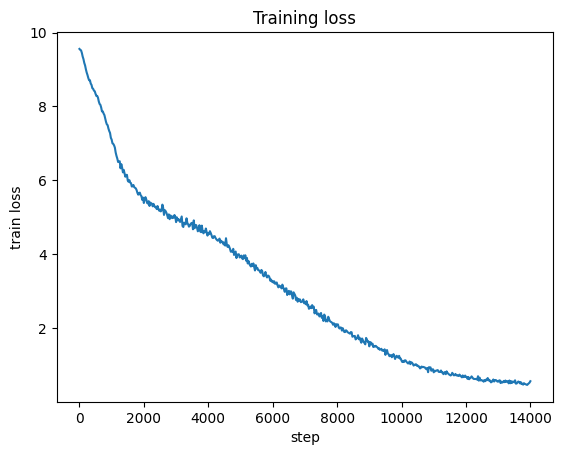

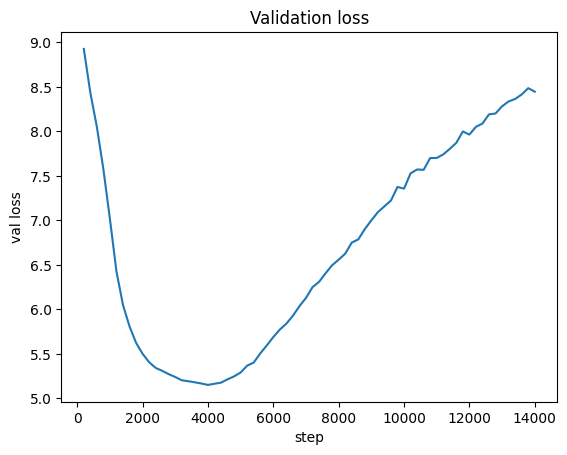

In [21]:
# Plot of the Training Curve
import matplotlib.pyplot as plt

def plot_curves(train_hist, val_hist):
    if len(train_hist) == 0 or len(val_hist) == 0:
        print("Not enough history to plot.")
        return

    t_steps, t_loss = zip(*train_hist)
    v_steps, v_loss = zip(*val_hist)

    plt.figure()
    plt.plot(t_steps, t_loss)
    plt.xlabel("step")
    plt.ylabel("train loss")
    plt.title("Training loss")
    plt.show()

    plt.figure()
    plt.plot(v_steps, v_loss)
    plt.xlabel("step")
    plt.ylabel("val loss")
    plt.title("Validation loss")
    plt.show()

plot_curves(train_hist, val_hist)

## Text Generation (Section 5.5)

In [25]:
ckpt_path = "/content/checkpoint_best.pt"
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

prompt = "The meaning of life is"
p = tokenizer.encode(prompt)

print("\n[Greedy]")
print(decode_ids(generate(model, p, 120, greedy=True)))

print("\n[Temp=0.9 Top-k=50]")
print(decode_ids(generate(model, p, 120, temperature=0.9, top_k=50)))

print("\n[Temp=0.9 Top-p=0.9]")
print(decode_ids(generate(model, p, 120, temperature=0.9, top_p=0.9)))


[Greedy]
The meaning of life is a man, and my lord, I' ll be a man. DUKE VINCENTIO: I am a man. DUKE VINCENTIO: I am not to be a man. DUKE VINCENTIO: I am a man, and I am a man. DUKE VINCENTIO: I am a man; and I am a man. DUKE VINCENTIO: I am a man that I am a man, and a man that I am a man' ll be a man. DUKE VINCENTIO: I am a man; for a man' ll be a man; for a man that I am a man' ll be a man' ll

[Temp=0.9 Top-k=50]
The meaning of life is not too; But you would follow you' d,' d. Come, you say, sir, sir, sir, for, I should have a prince of your own. First Citizen: I' ll make the you do you: And think you that you must be a king. First Senator: Ay, I' ll never not a cause. Second Senator: What you be more,' ll come to be a little to him; but an hour as he is a better. SICINIUS: The matter. BRUTUS: This is a thing; a little, sir, my good house; I

[Temp=0.9 Top-p=0.9]
The meaning of life is born: Or stand in the first, with our cares, And Lewis of the princes' s fight, his conscience,

In [35]:
def print_samples(tag, model):
    prompt = "The meaning of life is"
    p = tokenizer.encode(prompt)

    print(f"\n==== {tag} ====")
    print("[Greedy]")
    print(decode_ids(generate(model, p, 120, greedy=True)))

    print("\n[Temp=0.9 Top-k=50]")
    print(decode_ids(generate(model, p, 120, temperature=0.9, top_k=50)))

    print("\n[Temp=0.9 Top-p=0.9]")
    print(decode_ids(generate(model, p, 120, temperature=0.9, top_p=0.9)))
    print("==============\n")

In [36]:
prompt = "The meaning of life is"

print("=== SCRATCH MODEL (trained) ===")
p_ids = tokenizer.encode(prompt)

# Match settings we’ll use for GPT-2
out_ids = generate(
    model,
    p_ids,
    max_new_tokens=120,
    temperature=0.9,
    top_k=50
)
print(decode_ids(out_ids))

=== SCRATCH MODEL (trained) ===
The meaning of life is too much. QUEEN ELIZABETH: My lord. KING RICHARD III: My lord, my lord of the king. QUEEN ELIZABETH: You shall be no more that may be my uncle; Or shall be my life, my son of my life. KING RICHARD II: But if I fear' d, my lord, I have he is most that, So many of your royal grace' s grave. KING RICHARD II: The most old lord, which which you must fly. KING RICHARD III: It, if I' s the king' s death hath made. BUCKINGHAM: Let' d, that thou


In [37]:
print("\n=== SCRATCH MODEL (top-p) ===")
out_ids_p = generate(
    model,
    p_ids,
    max_new_tokens=120,
    temperature=0.9,
    top_p=0.9
)
print(decode_ids(out_ids_p))


=== SCRATCH MODEL (top-p) ===
The meaning of life is here to deny: they have made your father' s bed; It is as a power to water to- night: He says to speak that, and small men that he is contented. QUEEN MARGARET: So it is the supreme, When it is a fair To be done! That, not the stocks, many conqueror, And humbly pluck' d at sweat, that knows it my father' d, And would have you see the this father' d my lord, And yet a wrong' d, And become an from the world' d in fear; And can be thus wears her eyes of


## Loading Pretrained Weights (Section 5.6)

In [38]:
!pip -q install transformers

import torch
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

In [39]:
hf_name = "gpt2"
gpt2_tok = GPT2TokenizerFast.from_pretrained(hf_name)
gpt2 = GPT2LMHeadModel.from_pretrained(hf_name, ignore_mismatched_sizes=True).to(device)
gpt2.eval()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [40]:
def run_scratch(prompt: str, mode: str = "topk"):
    p = tokenizer.encode(prompt)
    if mode == "topk":
        ids = generate(model, p, max_new_tokens=120, temperature=0.9, top_k=50)
    else:
        ids = generate(model, p, max_new_tokens=120, temperature=0.9, top_p=0.9)
    return decode_ids(ids)

def run_gpt2(prompt: str, mode: str = "topk"):
    inp = gpt2_tok(prompt, return_tensors="pt").to(device)
    if mode == "topk":
        out = gpt2.generate(**inp, max_new_tokens=120, do_sample=True, temperature=0.9, top_k=50,
                           pad_token_id=gpt2_tok.eos_token_id)
    else:
        out = gpt2.generate(**inp, max_new_tokens=120, do_sample=True, temperature=0.9, top_p=0.9,
                           pad_token_id=gpt2_tok.eos_token_id)
    return gpt2_tok.decode(out[0], skip_special_tokens=True)

prompt = "The meaning of life is"

scratch_topk = run_scratch(prompt, "topk")
gpt2_topk    = run_gpt2(prompt, "topk")

scratch_topp = run_scratch(prompt, "topp")
gpt2_topp    = run_gpt2(prompt, "topp")

print("\n================== TOP-K (k=50, temp=0.9) ==================")
print("\n[SCRATCH TRAINED]\n", scratch_topk)
print("\n[GPT-2 PRETRAINED]\n", gpt2_topk)

print("\n================== TOP-P (p=0.9, temp=0.9) ==================")
print("\n[SCRATCH TRAINED]\n", scratch_topp)
print("\n[GPT-2 PRETRAINED]\n", gpt2_topp)


================== TOP-K (k=50, temp=0.9) ==================

[SCRATCH TRAINED]
 The meaning of life is my lord. KING RICHARD III: And in her daughter, with her that' s sake, her, if thou hast rather not yet she in her. Why' s your her soul, I take her eye of blood To take her honour' s dead; For old son, And she doth Romeo I would not her son? NORTHUMBERLAND: The king is she is she is come in their own fortune in the king, When I did say you on her; But how she be to her. KING HENRY BOLINGBROKE: God' t from her, let your bed that she was there be her for her

[GPT-2 PRETRAINED]
 The meaning of life is not so much that every person's life, even if they say so out loud and in tones that have long ago died, is the best, but that every life, even when very young and in fact very well lived, is the worst. If you want to get a sense of the difference people have made in human behavior, you will have to make some comparison to the way your parents dealt with problems such as depression or o